# Image Processing

This notebook tests diferents pre processes techiniques for Optical Character Recognition.

---

## Packages and Libraries


In [1]:
# python libs

from cv2 import imread

from matplotlib.pyplot import imshow, axis, show

from tqdm import tqdm

from os import mkdir, listdir
from os.path import exists

In [2]:
%cd ..

/home/gabriel-emannuel/ufcg/projeto-I/OCR-Experiments


In [3]:
# src code

from src.interfaces import PreProcessInterface

from src.preprocess import *

---

## Configurations


In [4]:
DATA_INPUT = "data/input-preprocess"

DATA_OUTPUT = "data/output-preprocess"

In [5]:
if not exists(DATA_INPUT) or not any(listdir(DATA_INPUT)): 
    raise Exception("Input data don't exist")

if not exists(DATA_OUTPUT):
    mkdir(DATA_OUTPUT)

---

## Load Images

In [6]:
def show_image(image_path: str) -> None:
    image_bytes = imread(image_path)
    imshow(image_bytes)
    axis("off")
    show()

In [7]:
IMAGE_PATHS = listdir(DATA_INPUT)

first image from Data Input

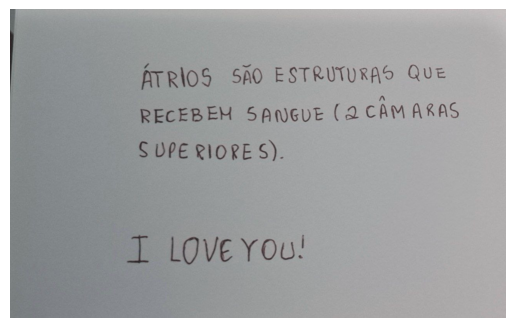

In [8]:
show_image(f"{DATA_INPUT}/{IMAGE_PATHS[0]}")

---

## Load Pre Processes Techniques

In [9]:
PRE_PROCESSES_TECHINIQUES: list[tuple[str, PreProcessInterface]] = [
    ("basic-pre-process-technique", PreProcessManagerV0()),
]

In [10]:
for technique_name, _ in PRE_PROCESSES_TECHINIQUES:
    if not exists(f"{DATA_OUTPUT}/{technique_name}"): 
        mkdir(f"{DATA_OUTPUT}/{technique_name}")

In [11]:
for technique_name, technique in PRE_PROCESSES_TECHINIQUES:
    for path in tqdm(IMAGE_PATHS, desc=f"Technique: {technique_name}", total=len(IMAGE_PATHS)):
        technique.preprocess(f"{DATA_INPUT}/{path}", f"{DATA_OUTPUT}/{technique_name}/{path}")

Technique: basic-pre-process-technique: 100%|██████████| 1/1 [00:00<00:00, 103.24it/s]


first image from every technique

---
Technique: basic-pre-process-technique


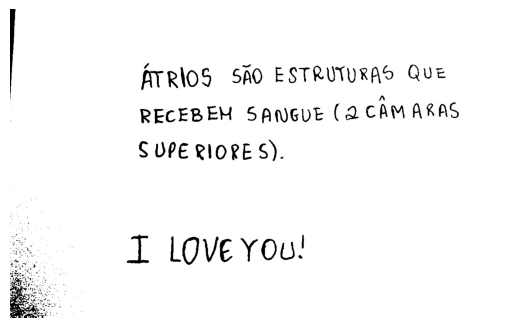

---


In [12]:
for technique_name, _ in PRE_PROCESSES_TECHINIQUES:
    images = listdir(f"{DATA_OUTPUT}/{technique_name}")
    print("---")
    print("Technique:", technique_name)
    show_image(f"{DATA_OUTPUT}/{technique_name}/{images[0]}")
    print("---")